In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet152
from tensorflow.keras.applications.resnet import preprocess_input,decode_predictions
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
model = ResNet152(weights = "imagenet")

model.summary()


Model: "resnet152"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 60,419,944 (230.48 MB)

 Trainable params: 60,268,520 (229.91 MB)

 Non-trainable params: 151,424 (591.50 KB)

In [ ]:
# prediction function

def prediction(image_path,model):
  img = load_img(image_path,target_size=(224,224))

  img_arr = img_to_array(img)

  # add batch dimension
  img_arr = np.expand_dims(img_arr,axis=0)

  img_arr = preprocess_input(img_arr)

  predict = decode_predictions(model.predict(img_arr),5)

  return predict[0]



In [ ]:
import requests

def download_image(url, save_path):
  """
  Downloads an image from a given URL and saves it to a specified path.

  Args:
      url: The URL of the image.
      save_path: The path where the image will be saved.
  """
  try:
    response = requests.get(url, stream=True)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(save_path, 'wb') as out_file:
      for chunk in response.iter_content(chunk_size=8192):
        out_file.write(chunk)
    print(f"Image downloaded successfully to {save_path}")
  except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")

In [ ]:
download_image("https://imgs.search.brave.com/n3U1QZg_7ph2oCnjuV5IU0_xB1RRDbZIH3-A9GuKBds/rs:fit:500:0:1:0/g:ce/aHR0cHM6Ly93d3cu/bWFnbm9saWFib3gu/Y29tL2Nkbi9zaG9w/L3Byb2R1Y3RzLzQy/LTYzOTk3MDcyXzEw/MjR4MTAyNC5qcGVn/P3Y9MTQ1MTkxMzIw/Ng","Ambystoma_maculatum.jpg")

Image downloaded successfully to Ambystoma_maculatum.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


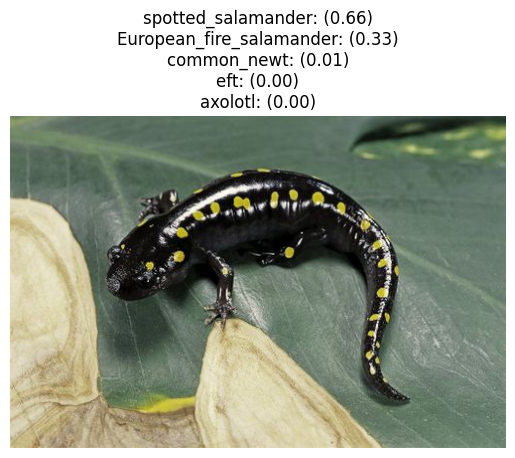

In [ ]:
img_path = "/content/Ambystoma_maculatum.jpg"

result = prediction(img_path,model)
label_1 = []
score_1 = []
for i,(imagnet_id,label,score) in enumerate(result):
  label_1.append(label)
  score_1.append(score)


img = load_img(img_path)
plt.imshow(img)
plt.title("\n".join(
    [f"{label_1[i]}: ({score_1[i]:.2f})" for i in range(5)]))
plt.axis("off")
plt.show()

#print(label_1)
#print(score_1)



